In [40]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import sys
import matplotlib.colors as mcolors
sys.path.append('../..')
sys.path.append('../../results')

from utils import *
from fig2.fig2_functions import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
(
    matrices0, matrices1, matrices2,
    matrices0_normal, matrices1_normal, matrices2_normal,
    L0, L1, L2,
    behaviours0, behaviours1, behaviours2,
    behaviours_normal0, behaviours_normal1, behaviours_normal2
) = load_fig2_data('../../data/fig2')

In [26]:
# --- Classify matrices by behavioural repertoire ---
classified = classify_all(matrices0, matrices1, matrices2,
                          behaviours0, behaviours1, behaviours2)

for i, sigma in enumerate(['0.2', '0.5', '1.0']):
    print(f'sigma={sigma}: {classified[i]["n_with_chaos"]} with chaos, '
          f'{classified[i]["n_without_chaos"]} without chaos')
    
idx2_without_chaos = classified[2]['idx_without_chaos']
L2_without_chaos = [L2[i] for i in idx2_without_chaos]

mat2_without_chaos = classified[2]['mat_without_chaos']
behaviours2_without_chaos = classified[2]['beh_without_chaos']


sigma=0.2: 45 with chaos, 5 without chaos
sigma=0.5: 52 with chaos, 7 without chaos
sigma=1.0: 1 with chaos, 5 without chaos


In [23]:
# --- Simulation parameters ---
T    = 20
N    = 100
dt   = 0.005
tauE = 0.1
tauI = 0.1

a    = np.ones(N)
c    = np.ones(N)
b    = np.zeros(N)
s    = np.zeros(N)
bias = np.zeros(N)

J = mat2_without_chaos[0]
W, _ = W_from_J(J, a, b, c)
initial_conditions = init_cond(J)

ic_fp        = 0.1  * initial_conditions[:, 0]
ic_orbit     = 0.1  * initial_conditions[:, 4]
ic_transient = 1.25 * initial_conditions[:, 79]

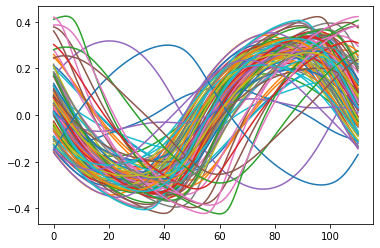

In [5]:
# --- Precompute fixed point and orbit ---
r_fp, _ = precompute_fixed_point(ic_fp, W, tauE, tauI, T, dt,
                                 a, b, c, s, bias, tail_avg_steps=500)

orbit_info = precompute_orbit(ic_orbit, W, tauE, tauI, T, dt,
                              a, b, c, s, bias, no_freqs=3, wash=10)

In [6]:
# --- Cue timings ---
quiet = 1
cues = {
    'stop'      : [1, quiet+3,  1, quiet+13, 1],
    'transient' : [1, quiet+15, 1],
    'go'        : [1, quiet+5,  0],
    'hold_on'   : [1, quiet+8,  1],
    'resume'    : [1, quiet+11, 1],
}

t, r, exts = solve_rk4_controlled(
    ic_orbit, ic_transient, W, cues, tauE, tauI, T, dt,
    a, b, c, s, bias, r_fp, orbit_info,
    sigma_ou=0.004242, tau_c=0.01, t_start_noise=0,
    rng=np.random.default_rng(13)
)

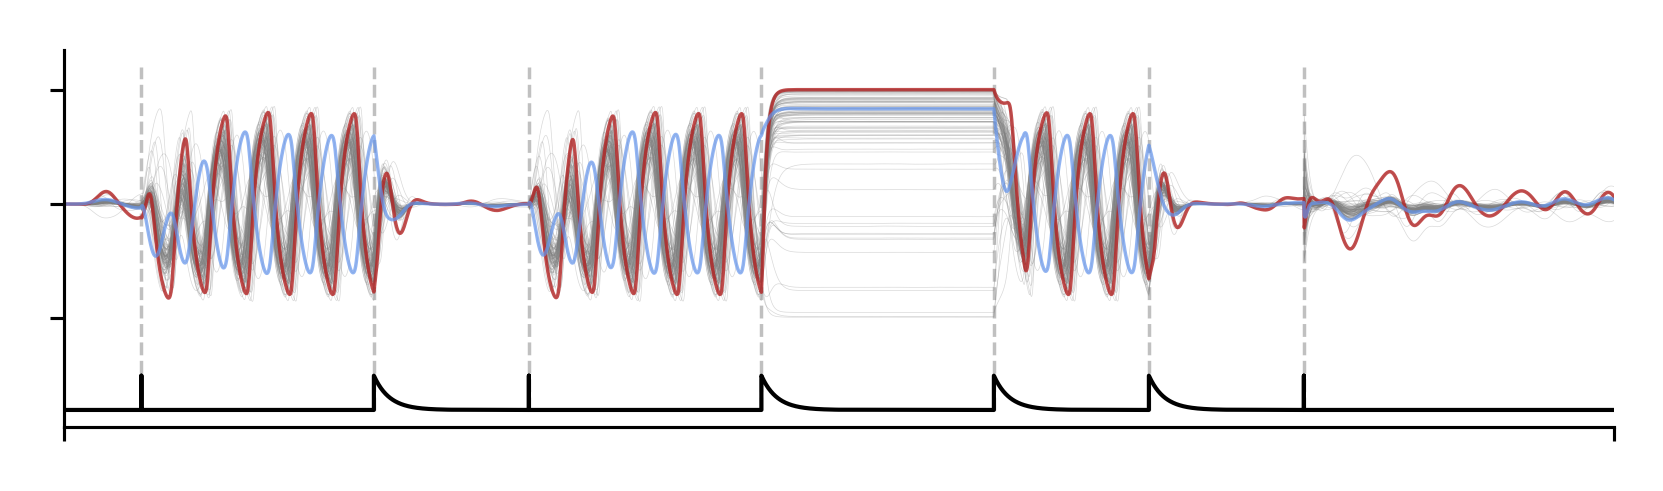

In [7]:
# --- Trajectory plot ---
input_events = [(1,1),(4,5),(6,6),(9,10),(12,13),(14,15),(16,16)]
idx = [17, 4, 90]  # highlighted neurons

fig, ax = plt.subplots(figsize=(4, 1), dpi=500)

for event in input_events:
    ax.vlines(x=event[0], ymin=-0.9, ymax=0.6,
              color='silver', linestyle='--', linewidth=0.5)

ax.plot(t, r, 'gray', linewidth=0.1, alpha=0.3)
ax.plot(t, r[:, idx[0]], color='firebrick',      linewidth=0.5, alpha=0.8)
ax.plot(t, r[:, idx[2]], color='cornflowerblue', linewidth=0.5, alpha=0.7)

# --- input signal trace ---
exp_events_decreasing = [2, 4, 5, 6]
step_times  = [0]
step_values = [0]

for i, (start, end) in enumerate(input_events):
    if i + 1 in exp_events_decreasing:
        step_times.extend([start, start])
        step_values.extend([0, 0.15])
        t_exp = np.linspace(start, end, 100)
        v_exp = 0.15 * np.exp(-5 * (t_exp - start) / (end - start))
        step_times.extend(t_exp)
        step_values.extend(v_exp)
    else:
        step_times.extend([start, start, end, end])
        step_values.extend([0, 0.15, 0.15, 0])

step_times.append(t[-1])
step_values.append(0)

ax.plot(step_times, np.array(step_values) - 0.9, color='k', linewidth=0.6, label='Input')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for spine in ax.spines.values():
    spine.set_linewidth(0.45)
ax.tick_params(width=0.45, pad=1, length=2, labelsize=5)

ax.set_xticks([0, 20]);    ax.set_xticklabels([])
ax.set_yticks([-0.5, 0, 0.5]); ax.set_yticklabels([])
ax.set_xlim(0, 20)

plt.show()

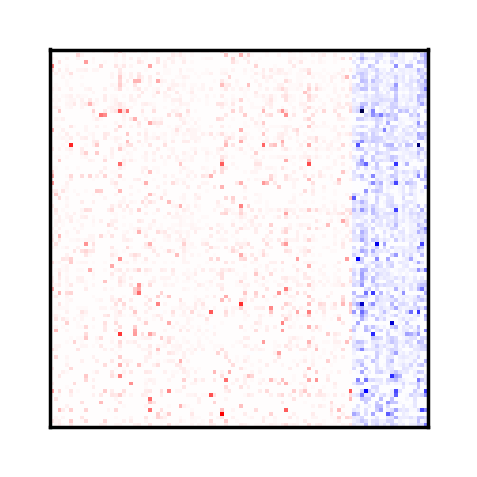

In [8]:
fig, ax = plt.subplots(figsize=(1, 1), dpi=500)
vmax = np.max(np.abs(W))
norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)
ax.imshow(W, cmap='seismic', norm=norm)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
ax.tick_params(width=0.5, pad=1, length=2)
ax.set_xticks([]); ax.set_yticks([])
plt.show()

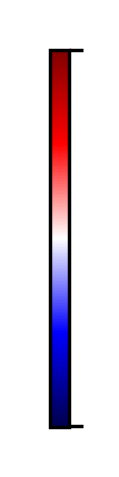

In [9]:
from matplotlib.cm import ScalarMappable
fig_cb, ax_cb = plt.subplots(figsize=(0.05, 1), dpi=500)
sm = ScalarMappable(norm=norm, cmap='seismic')
sm.set_array([])
cbar = fig_cb.colorbar(sm, cax=ax_cb)
cbar.outline.set_linewidth(0.5)
cbar.ax.tick_params(width=0.5, length=2, labelsize=6)
cbar.set_ticks([-34, 34])
cbar.ax.set_yticklabels([])
plt.show()

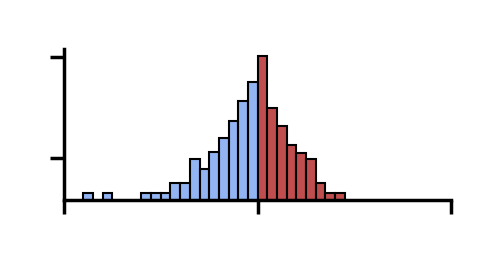

In [10]:
x = W.ravel()
binwidth = 2
max_abs = np.ceil(np.max(np.abs(x)) / binwidth) * binwidth
bins = np.arange(-max_abs, max_abs + binwidth, binwidth)

fig, ax = plt.subplots(figsize=(1, 0.4), dpi=500)
x_neg = x[x < 0]
x_pos = x[x > 0]
_, _, patches_neg = ax.hist(x_neg, bins=bins, color='cornflowerblue', edgecolor='k', linewidth=0.3)
_, _, patches_pos = ax.hist(x_pos, bins=bins, color='firebrick',      edgecolor='k', linewidth=0.3)
for p in patches_neg:
    p.set_facecolor((*p.get_facecolor()[:3], 0.7))
for p in patches_pos:
    p.set_facecolor((*p.get_facecolor()[:3], 0.8))
ax.set_yscale('log')
ax.set_yticks([10, 7000]);  ax.set_yticklabels([])
ax.set_xticks([-40, 0, 40]); ax.set_xticklabels([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.tick_params(width=0.5, pad=1, length=2)
plt.show()

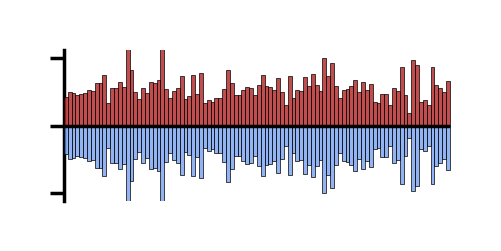

In [13]:
def plot_EI_received(W, nE=80, nI=20):
    """
    Bar plot of total excitatory and inhibitory input received by each neuron,
    with net input overlaid as a line.

    Parameters
    ----------
    W   : np.ndarray, shape (N, N)
    nE  : int — number of excitatory neurons (first nE columns)
    nI  : int — number of inhibitory neurons (next nI columns)
    """
    N = W.shape[0]
    assert nE + nI == N
    exc = np.sum(np.clip(W[:, :nE],      0, None), axis=1)
    inh = np.sum(np.clip(W[:, nE:nE+nI], None, 0), axis=1)
    net = exc + inh
    x   = np.arange(N)

    fig, ax = plt.subplots(figsize=(1, 0.4), dpi=500)
    ax.bar(x, exc, width=1, facecolor=(0.698, 0.133, 0.133, 0.8),
           edgecolor='k', linewidth=0.1, zorder=3)
    ax.bar(x, inh, width=1, facecolor=(0.392, 0.584, 0.929, 0.7),
           edgecolor='k', linewidth=0.1, zorder=3)
    ax.plot(x, net, color='k', lw=0.5, zorder=4)
    ax.hlines(0, -0.5, N, lw=0.1, color='k', zorder=2)
    ax.set_xlim(-0.5, N - 0.1)
    ax.set_ylim(-67, 67)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.tick_params(width=0.5, pad=1, length=2)
    ax.set_xticks([])
    ax.set_yticks([-60, 0, 60]); ax.set_yticklabels(['', '', ''])
    plt.show()
plot_EI_received(W, nE=80, nI=20)

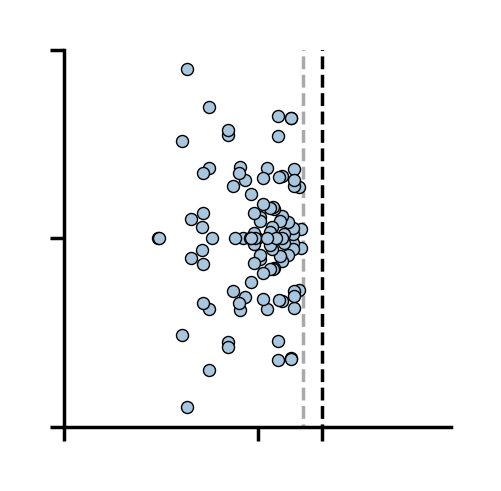

In [29]:
evaluesJ = L2_without_chaos[0]
fig, ax = plt.subplots(figsize=(1, 1), dpi=500)
ax.axvline(1.0, -3, 3, color="k", linestyle="--", linewidth=0.5,zorder=0)
ax.axvline(0.7, -3, 3, color="darkgray", linestyle="--", linewidth=0.5,zorder=0)
ax.scatter(evaluesJ.real,evaluesJ.imag ,s=3, color='#a8c6de' ,alpha=1, edgecolor='k',linewidth=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    
ax.tick_params(width=0.5, pad=1, length=2)
ax.set_xticks([-3,0,1])
ax.set_xticklabels([])
ax.set_yticks([-3,0,3])
ax.set_yticklabels([])

ax.set_xlim(-3,3)
ax.set_ylim(-3,3)
plt.show()

In [36]:
# --- Precompute deterministic trajectories ---

ic_fp = 0.1*initial_conditions[:,0]
ic_orbit = 0.1*initial_conditions[:,4]
ic_transient = 1.25*initial_conditions[:,79] #1.25
ic_baseline = np.zeros(N)

t, r_transient = solve_rk4_springBox(ic_transient, W, tauE, tauI, T, dt, a, b, c, bias)
_, r_orbit     = solve_rk4_springBox(ic_orbit,     W, tauE, tauI, T, dt, a, b, c, bias)
_, r_fp        = solve_rk4_springBox(ic_fp,        W, tauE, tauI, T, dt, a, b, c, bias)
r_baseline     = np.zeros((len(t), N))

In [37]:
# --- Experiment parameters ---
noise_levels = np.array([0.0001, 0.0002, 0.0003, 0.0004, 0.0005], dtype=float)
n_trials     = 10
tau_c        = 0.01
trial_seeds  = [0, 5, 202, 89, 113, 114, 212, 116, 142, 239]

quint = N // 5
nE    = 4 * quint

ICs = {
    "baseline" : ic_baseline,
    "fp"       : ic_fp,
    "orbit"    : ic_orbit,
    "transient": ic_transient,
}
ic_names = list(ICs.keys())

det_trajs = {
    "baseline" : r_baseline,
    "fp"       : r_fp,
    "orbit"    : r_orbit,
    "transient": r_transient,
}

In [38]:
# --- Main noise experiment loop ---
s_n_save   = 0.0003
n_ics      = len(ic_names)

ratios_sum = np.zeros((len(noise_levels), n_trials, n_ics, N))
ratios_I   = np.zeros((len(noise_levels), n_trials, n_ics, N))
ratios_E   = np.zeros((len(noise_levels), n_trials, n_ics, N))
rmse       = np.zeros((len(noise_levels), n_trials, n_ics))

I_exc_save_by_ic = {}
I_inh_save_by_ic = {}
tvec_save = None

for s_idx, s_n in enumerate(noise_levels):
    sigma_ou = sigma_ou_from_s_n(s_n, tau_c)
    for k, seed in enumerate(trial_seeds):
        for ic_idx, name in enumerate(ic_names):
            tvec, r = solve_rk4_noisy_springBox(
                ICs[name], W, tauE, tauI, T, dt, a, b, c, bias,
                sigma_ou=sigma_ou, tau_c=tau_c, t_start_noise=0.0,
                rng=np.random.default_rng(seed)
            )
            r_det = det_trajs[name]
            diff  = r - r_det
            rmse[s_idx, k, ic_idx] = np.linalg.norm(diff, ord='fro') / np.sqrt(diff.shape[0] * N)

            I_exc, I_inh = recurrent_EI_currents(r, W, nE=nE)
            ratios_sum[s_idx, k, ic_idx] = global_ratio_per_neuron(I_exc, I_inh, denom_mode="sum")
            ratios_I  [s_idx, k, ic_idx] = global_ratio_per_neuron(I_exc, I_inh, denom_mode="I")
            ratios_E  [s_idx, k, ic_idx] = global_ratio_per_neuron(I_exc, I_inh, denom_mode="E")

            if np.isclose(s_n, s_n_save) and (k == 0):
                I_exc_save_by_ic[name] = I_exc
                I_inh_save_by_ic[name] = I_inh
                tvec_save = tvec

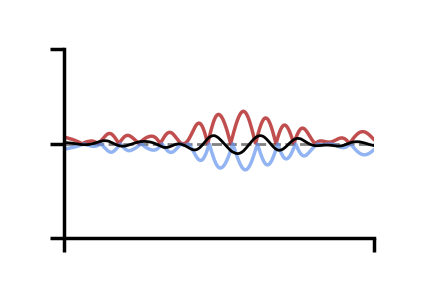

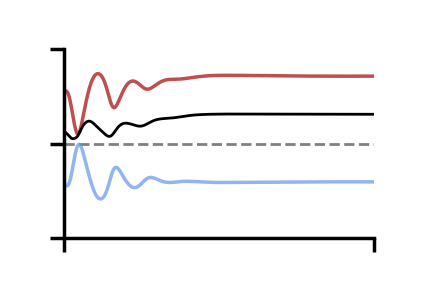

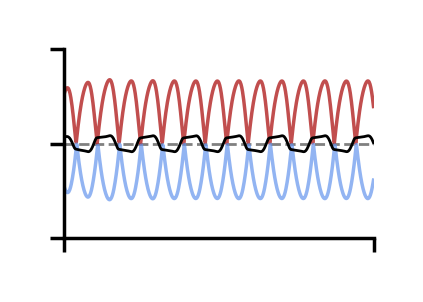

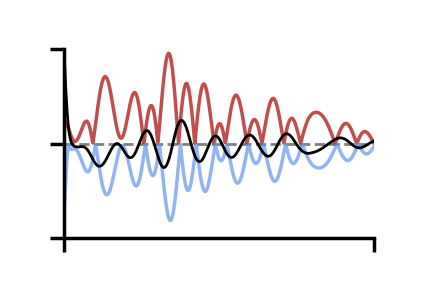

In [41]:
# --- EI current traces ---
ylims  = [[-1.2, 1.2], [-10, 10], [-10, 10], [-1.2, 1.2]]
starts = [200, 100, 200, 0]
ends   = [1000, 900, 1000, 800]
k_neuron = 19

for idx, name in enumerate(ic_names):
    plot_EI_trace_one_ic(
        tvec_save, I_exc_save_by_ic[name], I_inh_save_by_ic[name],
        k=k_neuron, ylim=ylims[idx], start=starts[idx], end=ends[idx]
    )

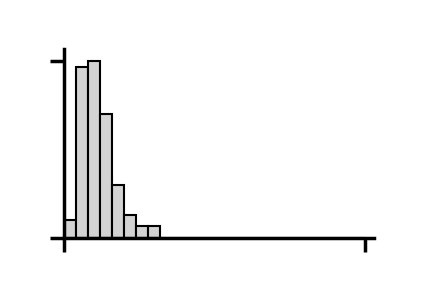

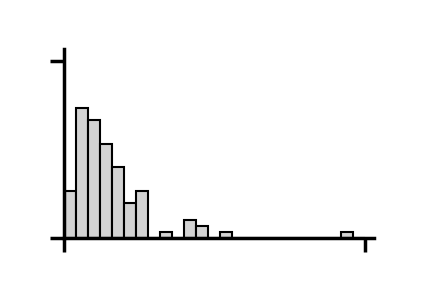

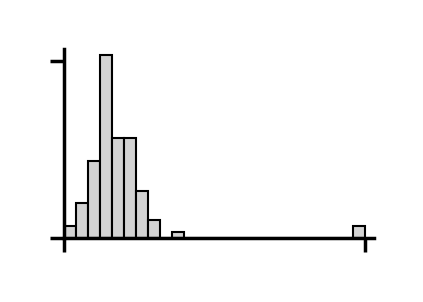

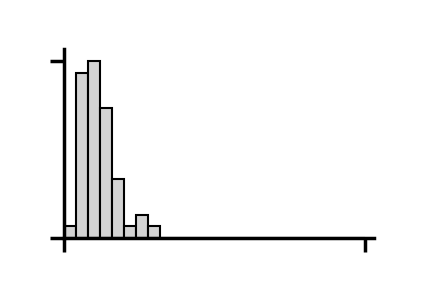

In [42]:
# --- Ratio histograms ---
idx_save    = int(np.where(np.isclose(noise_levels, s_n_save))[0][0])
bin_edges   = np.linspace(0.0, 1.0, 26)

for ic_idx, name in enumerate(ic_names):
    vals = ratios_sum[idx_save, 0, ic_idx, :]
    fig, ax = plt.subplots(figsize=(0.8, 0.5), dpi=500)
    ax.hist(vals, bins=bin_edges, linewidth=0.3, color='lightgray', edgecolor='k')
    ax.set_xlim([0, 1.03]); ax.set_ylim([0, 32])
    ax.set_xticks([0, 1]);  ax.set_xticklabels(['', ''])
    ax.set_yticks([0, 30]); ax.set_yticklabels(['', ''])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    ax.tick_params(width=0.5, pad=1, length=2, labelsize=5)
    plt.show()

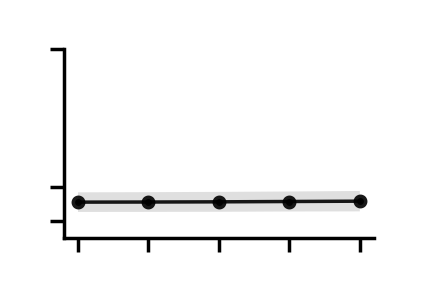

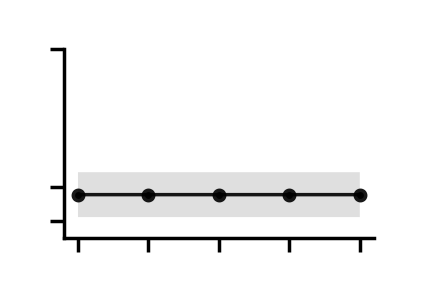

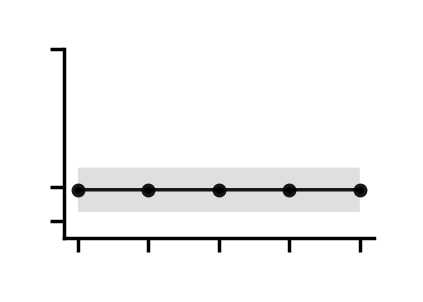

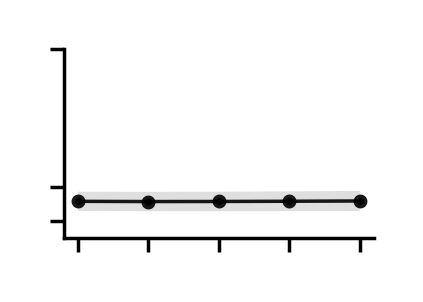

In [43]:
# --- Ratio vs noise level ---
means = np.zeros((len(ic_names), len(noise_levels)))
stds  = np.zeros((len(ic_names), len(noise_levels)))
for ic_idx in range(len(ic_names)):
    for i in range(len(noise_levels)):
        flat = ratios_sum[i, :, ic_idx, :].ravel()
        means[ic_idx, i] = np.mean(flat)
        stds [ic_idx, i] = np.std(flat)

for ic_idx, name in enumerate(ic_names):
    fig, ax = plt.subplots(figsize=(0.8, 0.5), dpi=500)
    ax.plot(noise_levels, means[ic_idx], marker='o', linewidth=0.5, markersize=1, color='k', alpha=0.9)
    ax.fill_between(noise_levels, means[ic_idx]-stds[ic_idx], means[ic_idx]+stds[ic_idx],
                    color='gray', alpha=0.25, linewidth=0, edgecolor='none')
    ax.set_xlim([0.00008, 0.00052]); ax.set_ylim([-0.1, 1])
    ax.set_xticks([0.0001, 0.0002, 0.0003, 0.0004, 0.0005]); ax.set_xticklabels(['','','','',''])
    ax.set_yticks([0, 0.2, 1]); ax.set_yticklabels(['','',''])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    ax.tick_params(width=0.5, pad=1, length=2, labelsize=5)
    plt.show()

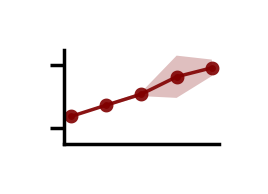

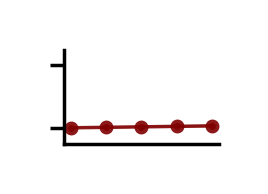

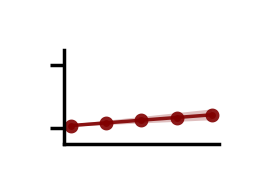

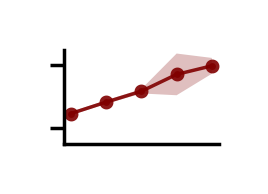

In [44]:
# --- RMSE vs noise level ---
means_r = np.zeros((len(ic_names), len(noise_levels)))
stds_r  = np.zeros((len(ic_names), len(noise_levels)))
for ic_idx in range(len(ic_names)):
    for i in range(len(noise_levels)):
        vals = rmse[i, :, ic_idx]
        means_r[ic_idx, i] = np.mean(vals)
        stds_r [ic_idx, i] = np.std(vals)

for ic_idx, name in enumerate(ic_names):
    fig, ax = plt.subplots(figsize=(0.4, 0.25), dpi=500)
    ax.plot(noise_levels, means_r[ic_idx], marker='o', linewidth=0.5, markersize=1, color='maroon', alpha=0.9)
    ax.fill_between(noise_levels, means_r[ic_idx]-stds_r[ic_idx], means_r[ic_idx]+stds_r[ic_idx],
                    color='maroon', alpha=0.25, linewidth=0, edgecolor='none')
    ax.set_xlim([0.00008, 0.00052]); ax.set_ylim([-0.005, 0.025])
    ax.set_xticks([]); ax.set_yticks([0, 0.02]); ax.set_yticklabels(['', ''])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    ax.tick_params(width=0.5, pad=1, length=2, labelsize=5)
    plt.show()